## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>


## <span style="color:black;"><strong>Datos de los estudiantes</strong></span>

In [5]:
nombre = input("📝 Ingresa tu nombre completo: ")
correo = input("📧 Ingresa tu correo electrónico: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de tu cédula: ")

📝 Ingresa tu nombre completo: Johan Castro
📧 Ingresa tu correo electrónico: jcamilo.castro@udea.edu.co
🔢 Ingresa los últimos 6 dígitos de tu cédula: 362024


In [6]:
# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

#CARGA DE DATOS

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Cargar el excel
ruta = '/content/drive/MyDrive/dataset_procesado.xlsx' # desde drive
df = pd.read_excel(ruta)

# Visulaizar una pequeña muestra de los datos
df.head()       #solo para tener conocimiento general de la base de datos

Mounted at /content/drive


,Empresa,Departamento,Municipio,Número único de identificación del sistema de tratamiento (NUPTAR),Caudal medio anual a la entrada (L/S),Caudal medio anual a la salida (LTS/SG),pH Unidades,Temperatura (°C),Sóidos Totales (mg/litro),DBO (Kg/Día),DQO (Kg/Día,Fecha de cargue
0,ACUEDUCTO ALCANTARILLADO Y ASEO DE COCONUCO S....,CAUCA,PURACE,4405,0.00,0.000,0.00,0.0,0.0,0.0,0.0,22-MAY-25
1,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2342,14.40,14.400,7.16,21.8,481.0,103.2,267.0,20-MAR-25
2,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2343,17.70,17.700,6.99,19.2,537.0,170.9,364.0,20-MAR-25
3,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2344,10.02,9.837,7.13,17.3,302.0,76.7,136.0,20-MAR-25
4,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2345,3.54,3.540,6.93,23.8,259.0,30.9,104.0,20-MAR-25


<Figure size 1200x600 with 0 Axes>

# Parte 1: Análisis univariado
Con los datos cargados (ingresados) se realiza un análisis univariado sobre la variable llamada: DQO (Kg/Día. Para esta variable, entonces se calculará lo siguiente:

- Medidas de tendencia central
- Medidas de dispersión
- Medidas de distribución
- Cálculo de percentiles

## Parte 1.1: Medidas de tendecia central
A partir de los datos de ingresos, calcula la media y la mediana. La moda no se calcula porque el tipo de datos de la variable escogida es continuo, entonces no es apropiado usar esa medida de tendencia central.

Medidas de tendencia central:
Media:   169.04 DQO [kg/día]
Mediana: 151.00 DQO [kg/día]
Tamaño de muestras: 1152


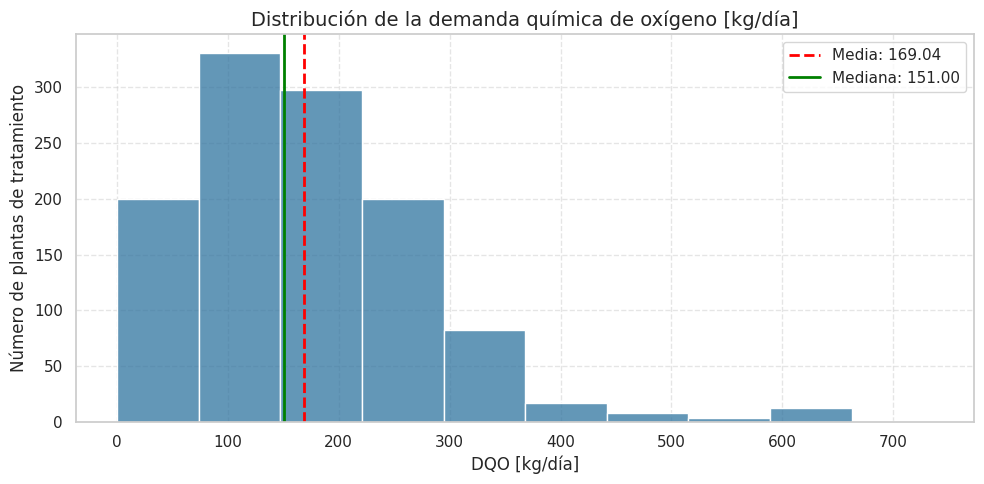

In [7]:
# Medidas de tendencia central
media = np.mean(df['DQO (Kg/Día'])
mediana = np.median(df['DQO (Kg/Día'])
tamano_muestras = len(df)

# Resultados
print("Medidas de tendencia central:")
print(f"Media:   {media:.2f} DQO [kg/día]")
print(f"Mediana: {mediana:.2f} DQO [kg/día]")
print(f"Tamaño de muestras: {tamano_muestras}")

# Visualización
plt.figure(figsize=(10, 5))
sns.histplot(df['DQO (Kg/Día'], bins=10, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')

plt.title("Distribución de la demanda química de oxígeno [kg/día]", fontsize=14)
plt.xlabel("DQO [kg/día]", fontsize=12)
plt.ylabel("Número de plantas de tratamiento", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

En la figura se observa que de las 1152 planta de tratamiento reportadas en la base de datos, en promedio, los vertimientos de agua tienen un valor de la demanda química de oxígeno de 169.04 kg/día; esta situación no nos permite definir si cumplen o no con la norma debido a que la normatividad establece los límites como mg/L y para eso necesitaríamos la variable relacionada con el caudal.

Si evaluamos la mediana, podemos ver que es muy cercano al valor de la media, lo que podría indicarnos que tal vez los datos tienen una distribución cercana a la normalidad.

## Parte 1.2: Medidas de dispersión
A partir de la muestra, se analizó qué tan dispersos están los datos respecto a su media. Para ello se calculan las siguientes medidas de dispersión:

- Rango
- Varianza
- Desviación estándar
- Coeficiente de variación

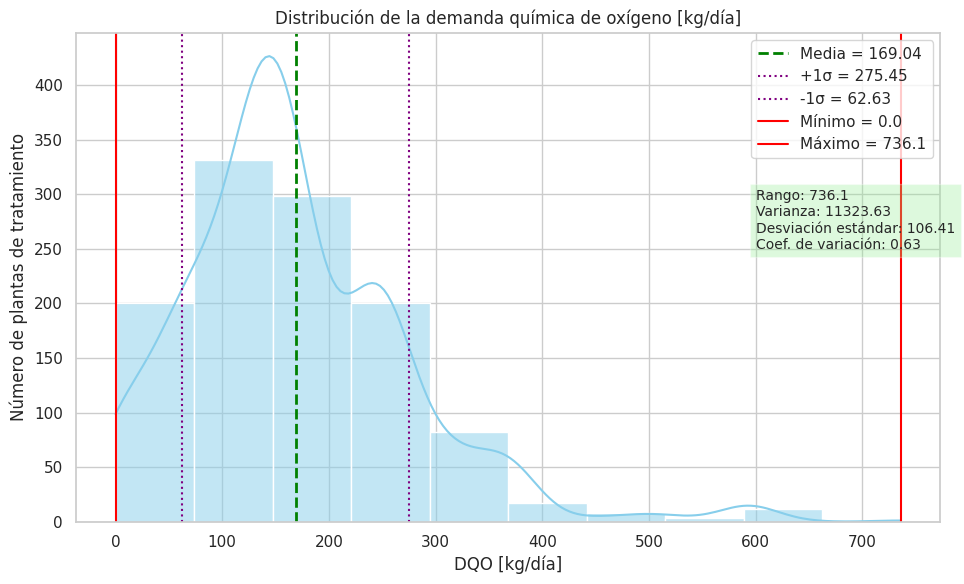

In [8]:
# Cálculo de medidas de dispersión
media = np.mean(df['DQO (Kg/Día'])
minimo = np.min(df['DQO (Kg/Día'])
maximo = np.max(df['DQO (Kg/Día'])
rango = maximo - minimo
varianza = np.var(df['DQO (Kg/Día'], ddof=1)
desviacion = np.std(df['DQO (Kg/Día'], ddof=1)
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['DQO (Kg/Día'], bins=10, kde=True, color='skyblue')

plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de la demanda química de oxígeno [kg/día]")
plt.xlabel("DQO [kg/día]")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(600, 250, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

Una vez calculadas las medidas de dispersión, es necesario comprender lo que es la demanda química de oxígeno y por qué es importante analizar con cuidado cada una de esas medidas.

La demanda química de oxígeno (DQO) nos dice qué tanto oxígeno es necesario para degradar la materia orgánica presente en las muestras (en este caso de agua residual), básicamente, una DQO alta indica que la contraminación es mayor y la norma establece límites dependiendo de la actividad o el origen de las aguas que se tratan en las plantas de tratamiento de aguas (PTAR).

Teniendo en cuenta los resultados de las medidas de dispersión podemos inferir que hay una alta variabilidad en los datos, lo que claramente indica que las PTAR tratan aguas de diferentes fuentes que no solo obedecen al departamento, si no que obedecen a al origen del agua y por consiguiente, a sus procesos de tratamiento y límites permisibles por la normatividad ambiental.

## Parte 1.3: cálculo de medidas de distribución
A partir de la variable seleccionada se analiza la distribución de los datos, donde se calcula:

- Asimetría
- Curtosis

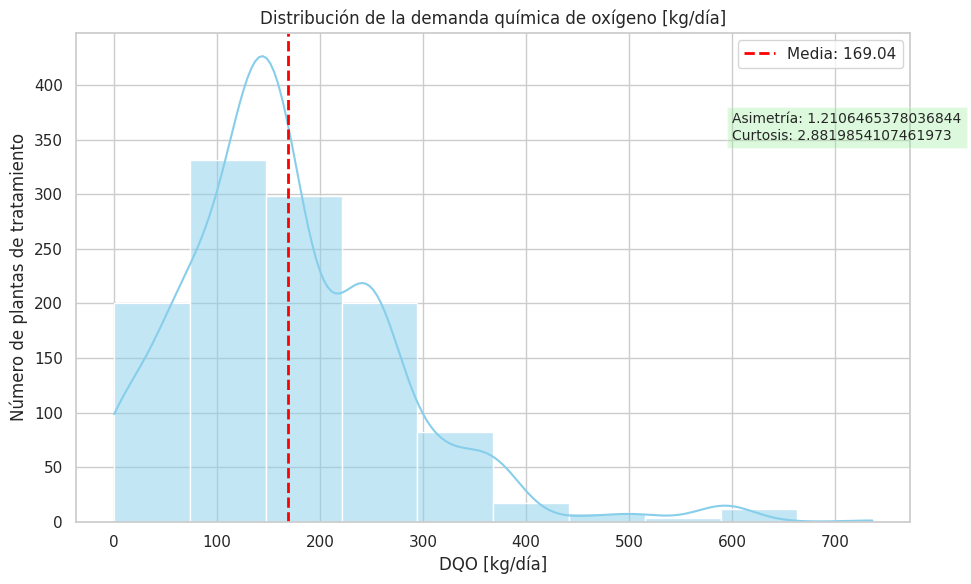

In [9]:
# Importar librerías
from scipy.stats import skew, kurtosis

# Cálculo de medidas
asimetria = skew(df['DQO (Kg/Día'])
curtosis_valor = kurtosis(df['DQO (Kg/Día'], fisher=True)  # Fisher=True: curtosis centrada en 0

# Visualización
plt.figure(figsize=(10, 6))
sns.histplot(df['DQO (Kg/Día'], bins=10, kde=True, color='skyblue')
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.title("Distribución de la demanda química de oxígeno [kg/día]")
plt.xlabel("DQO [kg/día]")
plt.ylabel("Número de plantas de tratamiento")
plt.legend(loc='upper right')

# Recuadro con medidas
texto = (
    f"Asimetría: {asimetria}\n"
    f"Curtosis: {curtosis_valor}"
)
plt.text(600, 350, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

Esos valores para la curtosis y la asimetría nos indican que en general las plantas operan o vierten aguas tratadas bajo los mismos rangos de DQO, sin embargo, existen desviaciones donde algunas PTAR vierten aguas con concentraciones de DQO altas y que son las que desplazan la media por encima de la mediana. Este comportamiento nos indica que los datos no tienen una distribución normal.

## Parte 1.4: cálculo de percentiles
A partir de la variable seleccionada se analiza la distribución de los datos en percentiles, donde se calcula lo siguiente:
- Percentiles
- Deciles
- Cuartiles

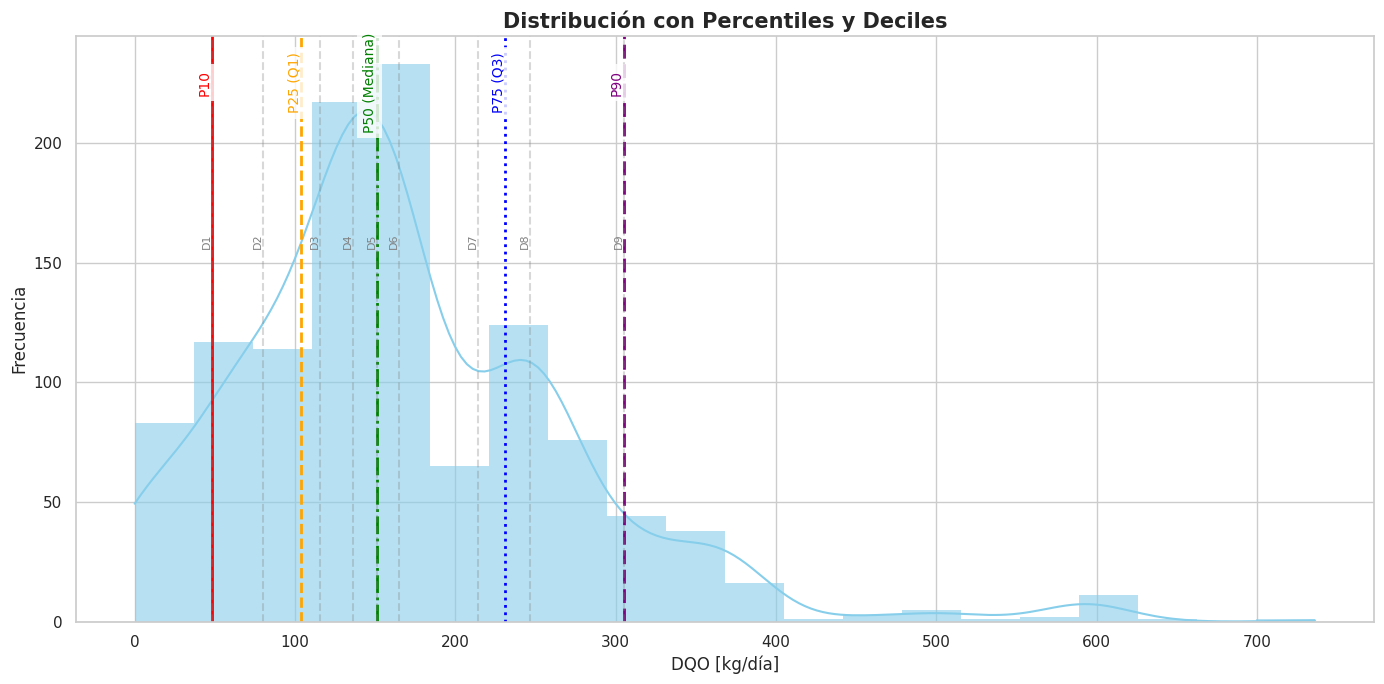

In [10]:
# Estilo visual
sns.set_theme(style="whitegrid")

# Cálculo de percentiles clave
percentiles = {
    'P10': {'valor': np.percentile(df['DQO (Kg/Día'], 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(df['DQO (Kg/Día'], 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(df['DQO (Kg/Día'], 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(df['DQO (Kg/Día'], 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(df['DQO (Kg/Día'], 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(df['DQO (Kg/Día'], i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 7))
sns.histplot(df['DQO (Kg/Día'], kde=True, color='skyblue', bins=20, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.92, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.65, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

plt.title("Distribución con Percentiles y Deciles", fontsize=15, fontweight='bold')
plt.xlabel("DQO [kg/día]")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

El comportamiento observado al dividir los datos en cuartiles, deciles y percentiles deja observar que en el país hay una heterogeneidad respecto a la infraestructura de saneamiento del país, donde se observa que si bien muchas plantas son eficientes en la remoción de DQO, otras no lo son tanto debido a como se mencionó anteriormente, la proveniencia de las aguas, la capacidad de operación de las plantas y la obsolencia de las tecnologías usadas.

# Parte 2: Análisis bivariado
Con los datos cargados (ingresados) se realiza un análisis bivariado sobre las variables llamadas: DQO (Kg/Día y Caudal medio anual a la entrada (L/S). El fin de este análisis es determinar qué tan relacionadas están ambas variables y para ello se calculará lo siguiente:
- Análisis de correlación.
- Chi-cuadrado.

## Parte 2.1: análisis de correlación

La idea de esta sección es mirar qué correlación hay entre el caudal medio anual y la demanda química de oxígeno, esperando que ambas variables se relacionen positivamente.

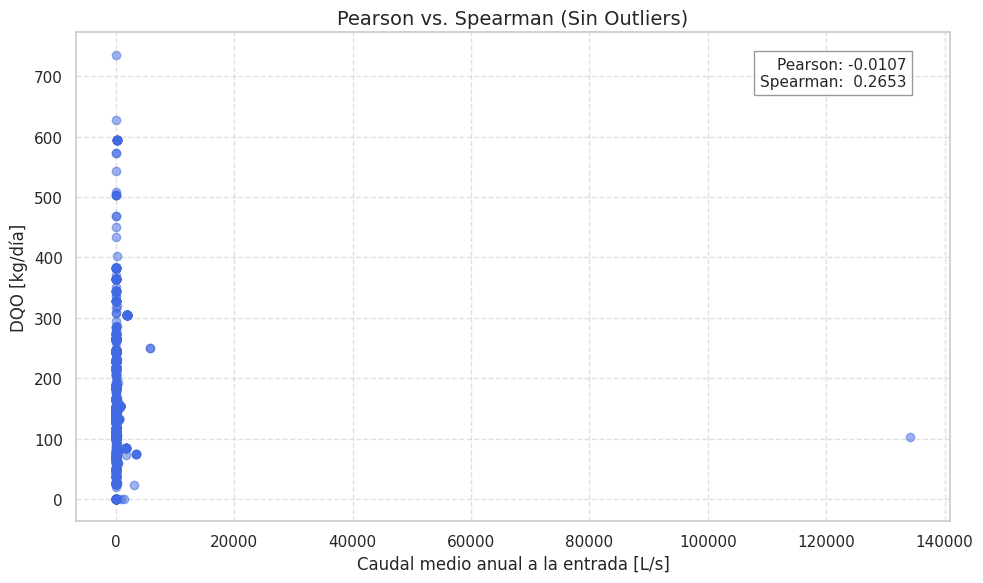

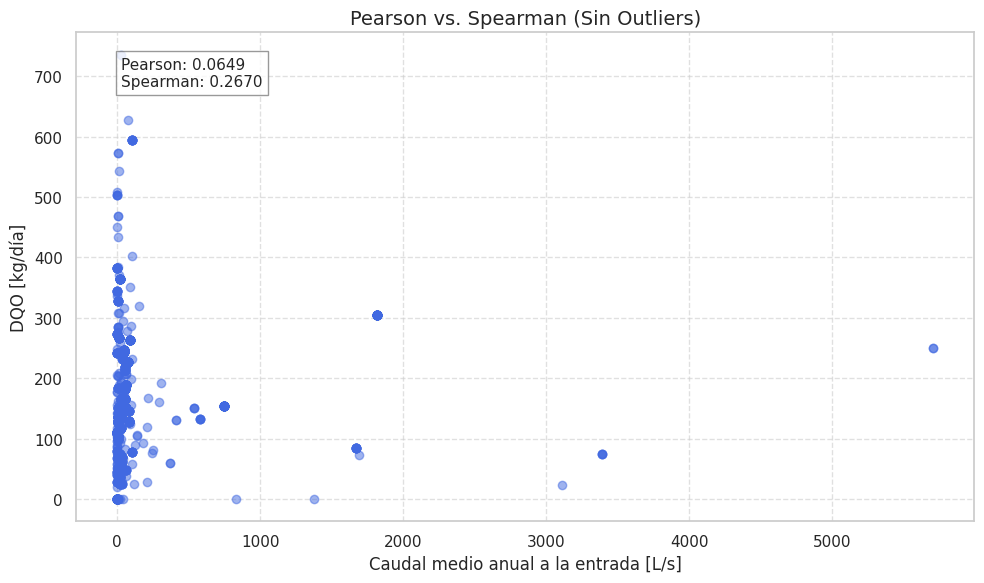

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# Pearson
r1, _ = pearsonr(df['Caudal medio anual a la entrada (L/S)'], df['DQO (Kg/Día'])

#spearman
r2, _ = spearmanr(df['Caudal medio anual a la entrada (L/S)'], df['DQO (Kg/Día'])

plt.figure(figsize=(10, 6))
plt.scatter(df['Caudal medio anual a la entrada (L/S)'], df['DQO (Kg/Día'], color="royalblue", alpha=0.5, label="Datos")

plt.title("Pearson vs. Spearman (Sin Outliers)", fontsize=14)
plt.xlabel("Caudal medio anual a la entrada [L/s]", fontsize=12)
plt.ylabel("DQO [kg/día]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

texto = f"Pearson: {r1: .4f}\nSpearman: {r2: .4f}"
plt.text(0.95, 0.95, texto, transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
         fontsize=11, verticalalignment='top', horizontalalignment='right')

plt.tight_layout()
plt.show()


# Eliminar cualquier caudal mayor a 20,000
df_limpio = df[df['Caudal medio anual a la entrada (L/S)'] < 20000].copy()

# Recalcular coeficientes con los datos "filtrados"
col_caudal = 'Caudal medio anual a la entrada (L/S)'
col_dqo = 'DQO (Kg/Día'

r_p, _ = pearsonr(df_limpio[col_dqo], df_limpio[col_caudal])
r_s, _ = spearmanr(df_limpio[col_dqo], df_limpio[col_caudal])

# Visualización
plt.figure(figsize=(10, 6))
plt.scatter(df_limpio[col_caudal], df_limpio[col_dqo], color="royalblue", alpha=0.5, label="Datos")

plt.title("Pearson vs. Spearman (Sin Outliers)", fontsize=14)
plt.xlabel("Caudal medio anual a la entrada [L/s]", fontsize=12)
plt.ylabel("DQO [kg/día]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

texto = f"Pearson: {r_p:.4f}\nSpearman: {r_s:.4f}"
plt.text(0.05, 0.95, texto, transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
         fontsize=11, verticalalignment='top')

plt.tight_layout()
plt.show()


La primera gráfica corresponde a los datos crudos, donde se puede concluir que de acuerdo al coeficiente de correlación de pearson, la relación lineal es prácticamente nula, mientras que el coeficiente de spearman nos dice que tal vez un aumento en el caudal termina en un aumento en la DQO.

En la segunda gráfica se elimina un dato atípico que contiene un valor muy alto en el caudal, sin embargo, no se observa mayor diferencia en los coeficientes. El cambio de signo en el coeficiente de correlación de pearson nos indica que ese dato "tiraba" un poco la tendencia hacia relaciones inversas, pero, como se mencionó, el valor es tan bajo que se concluye que no hay relación lineal (o es casi nula).

## Parte 2.2: Chi-caudrado

Cómo Chi-cuadrado es un método no paramétrico para cariables categóricas, las variables a analizar en este caso son los departamentos con los niveles de DQO que se convertirá de númerico en categórico haciendo que se atribuyan 3 categorías a los valores (bajo, medio y alto). Lo anterior, con el fin de relacionar los departamentos con los niveles de contaminación.

Nota: En análisis anteriores se dijo que valores de DQO iguales a cero corresponden a registros que no se tienen, es por eso que con el fin de que el resultado del chi cuadrado no se vea afectado por la cantidad de registros con ese valor en la DQO, se filtran los datos escogiendo los que tienen valores diferentes de cero (como hablamos de concentración, todos los datos son positivos).

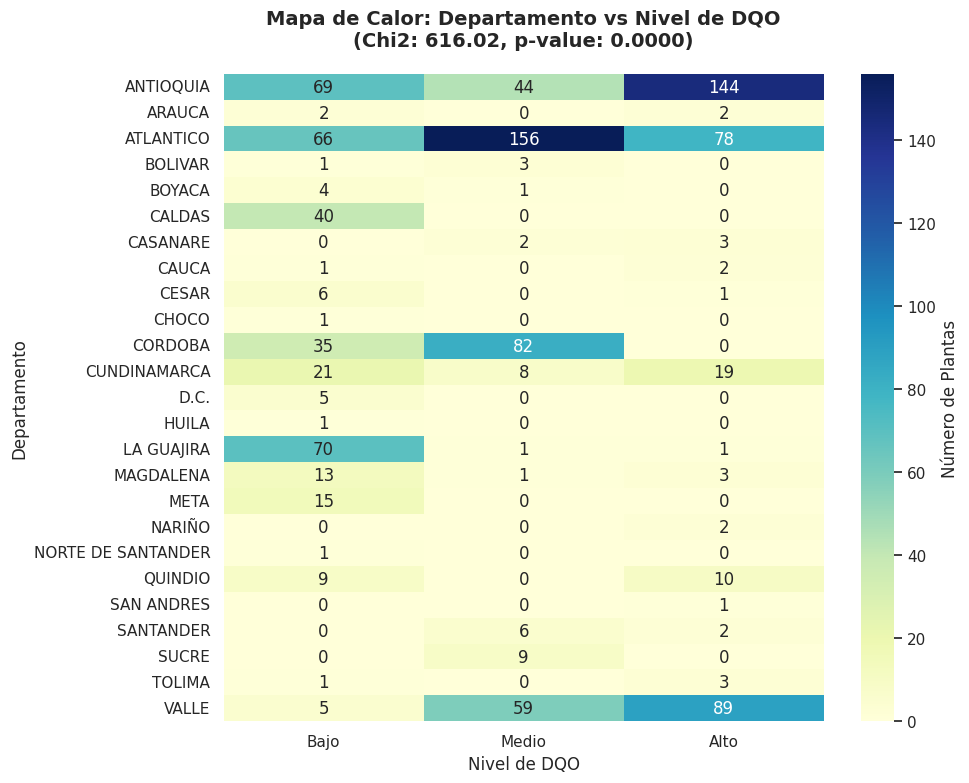

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Quitamos filas con DQO = 0 que puedan sesgar el análisis
df_filtrado = df[df['DQO (Kg/Día'] > 0].copy()

# Categorización de la DQO (Bajo, Medio, Alto)
# Usamos qcut para que los grupos tengan una cantidad similar de datos
df_filtrado['Nivel_DQO'] = pd.qcut(df_filtrado['DQO (Kg/Día'], q=3, labels=["Bajo", "Medio", "Alto"])

# Tabla de contingencia
tabla = pd.crosstab(df_filtrado['Departamento'], df_filtrado['Nivel_DQO'])

# Cálculo de Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(tabla)

# Visualización: Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(tabla, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Número de Plantas'})

plt.title(f"Mapa de Calor: Departamento vs Nivel de DQO\n(Chi2: {chi2:.2f}, p-value: {p:.4f})",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Nivel de DQO", fontsize=12)
plt.ylabel("Departamento", fontsize=12)

plt.tight_layout()
plt.show()

Los resultados de la prueba de chi-cuadrado revelan que la concentración de la DQO no es uniforme a lo largo del país y que hay cierta diferencia relacionada con factores regionales como la densidad poblacional, el tipo de industria o la eficiencia de tratamiento; que tienen impacto directo en la calidad del agua vertida.

# Parte 3: Análisis Multivariado

Teniendo presente la base de datos con la que se ha venido trabajando, se realizará un análisis de componenetes principales para reducir la dimensionalidad de la matriz y encontrar componentes que ayuden a describir la variabilidad de las observaciones.

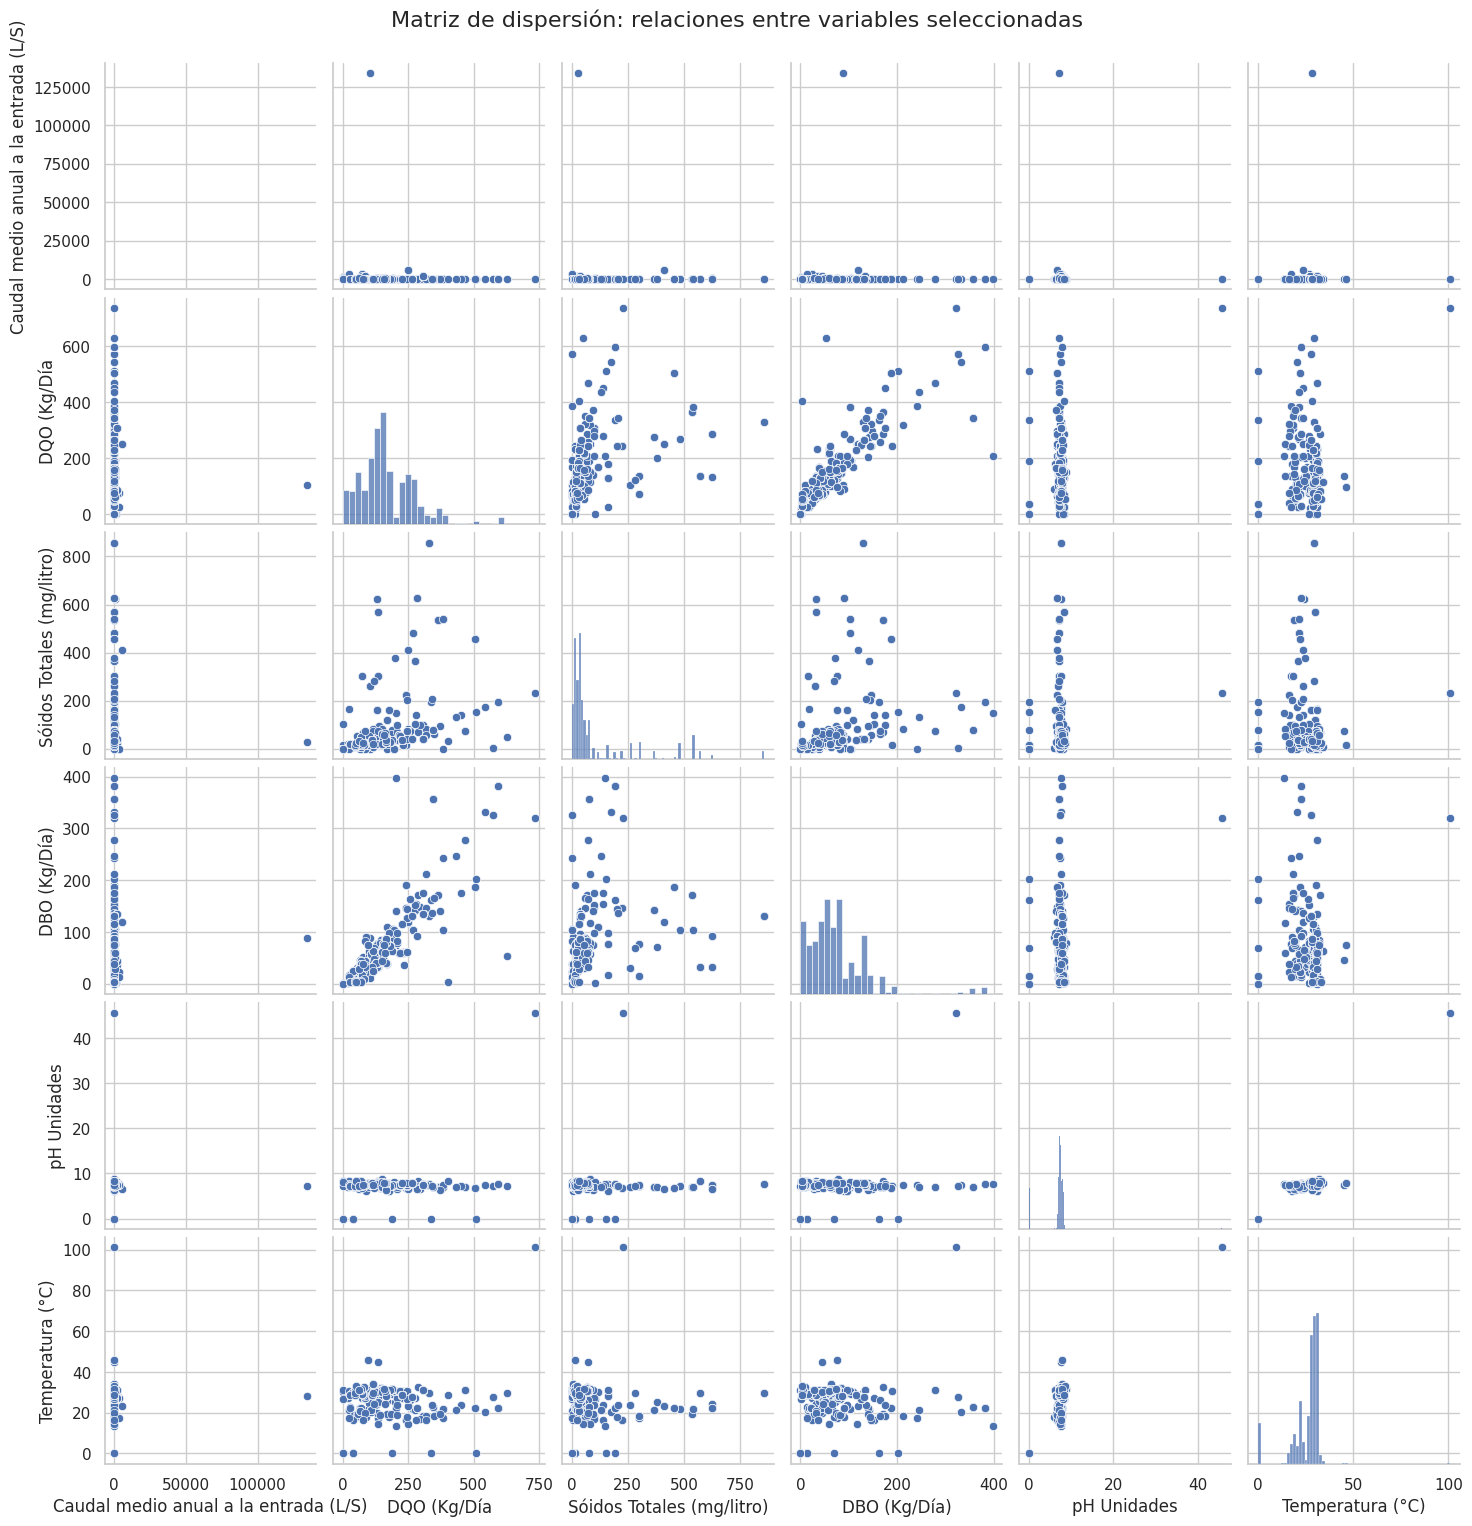

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seleccionar las columnas numéricas relevantes para PCA
numerical_cols = ['Caudal medio anual a la entrada (L/S)', 'DQO (Kg/Día', 'Sóidos Totales (mg/litro)',
                             'DBO (Kg/Día)', 'pH Unidades', 'Temperatura (°C)']

# Crear un DataFrame para el PCA y pairplot
# y eliminando filas con NaN en cualquiera de las columnas seleccionadas
df_for_analysis = df[numerical_cols].dropna()

# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(df_for_analysis)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Visualización con pairplot
sns.pairplot(df_for_analysis, diag_kind='hist', corner=False)
plt.suptitle('Matriz de dispersión: relaciones entre variables seleccionadas', fontsize=16, y=1.02)
plt.show()

Se debe aclarar que no se tuvo en cuenta una variable que permitiera ver cómo son los tratamientos por departamentos porque el objeto del análsis por ahora se centra en la relación de las variables, entonces su interpretación va a partir de ahí. Hay un comportamiento muy particular entre algunas variables, algunas se esperaban, otras no, pero para realizar mejor ese análisis hay que hacer una limpieza breve que se debe a valores imposibles en algunas de las varibales. El pH solo puede tomar valores entre 0 y 14, por lo que observar un dato con un valor de 45 nos indica que fue un error de digitación. En la temperatura hay un valor de cero y otro de 100, lo que se encuentra en extremos que son un poco imposibles para las plantas de tratamiento de aguas (a no ser que en el caso de la temperatura de 100 °C se hable de agua que se vierte de inmediato al medio ambiente y procede de una caldera). Adicionalmente, se eliminará ese outlier del caudal para ver una relación un poco más cercana y que ese dato no arrastre todo el peso de los componentes, por ello se volverá a realizar el análisis como se muestra a continuación.

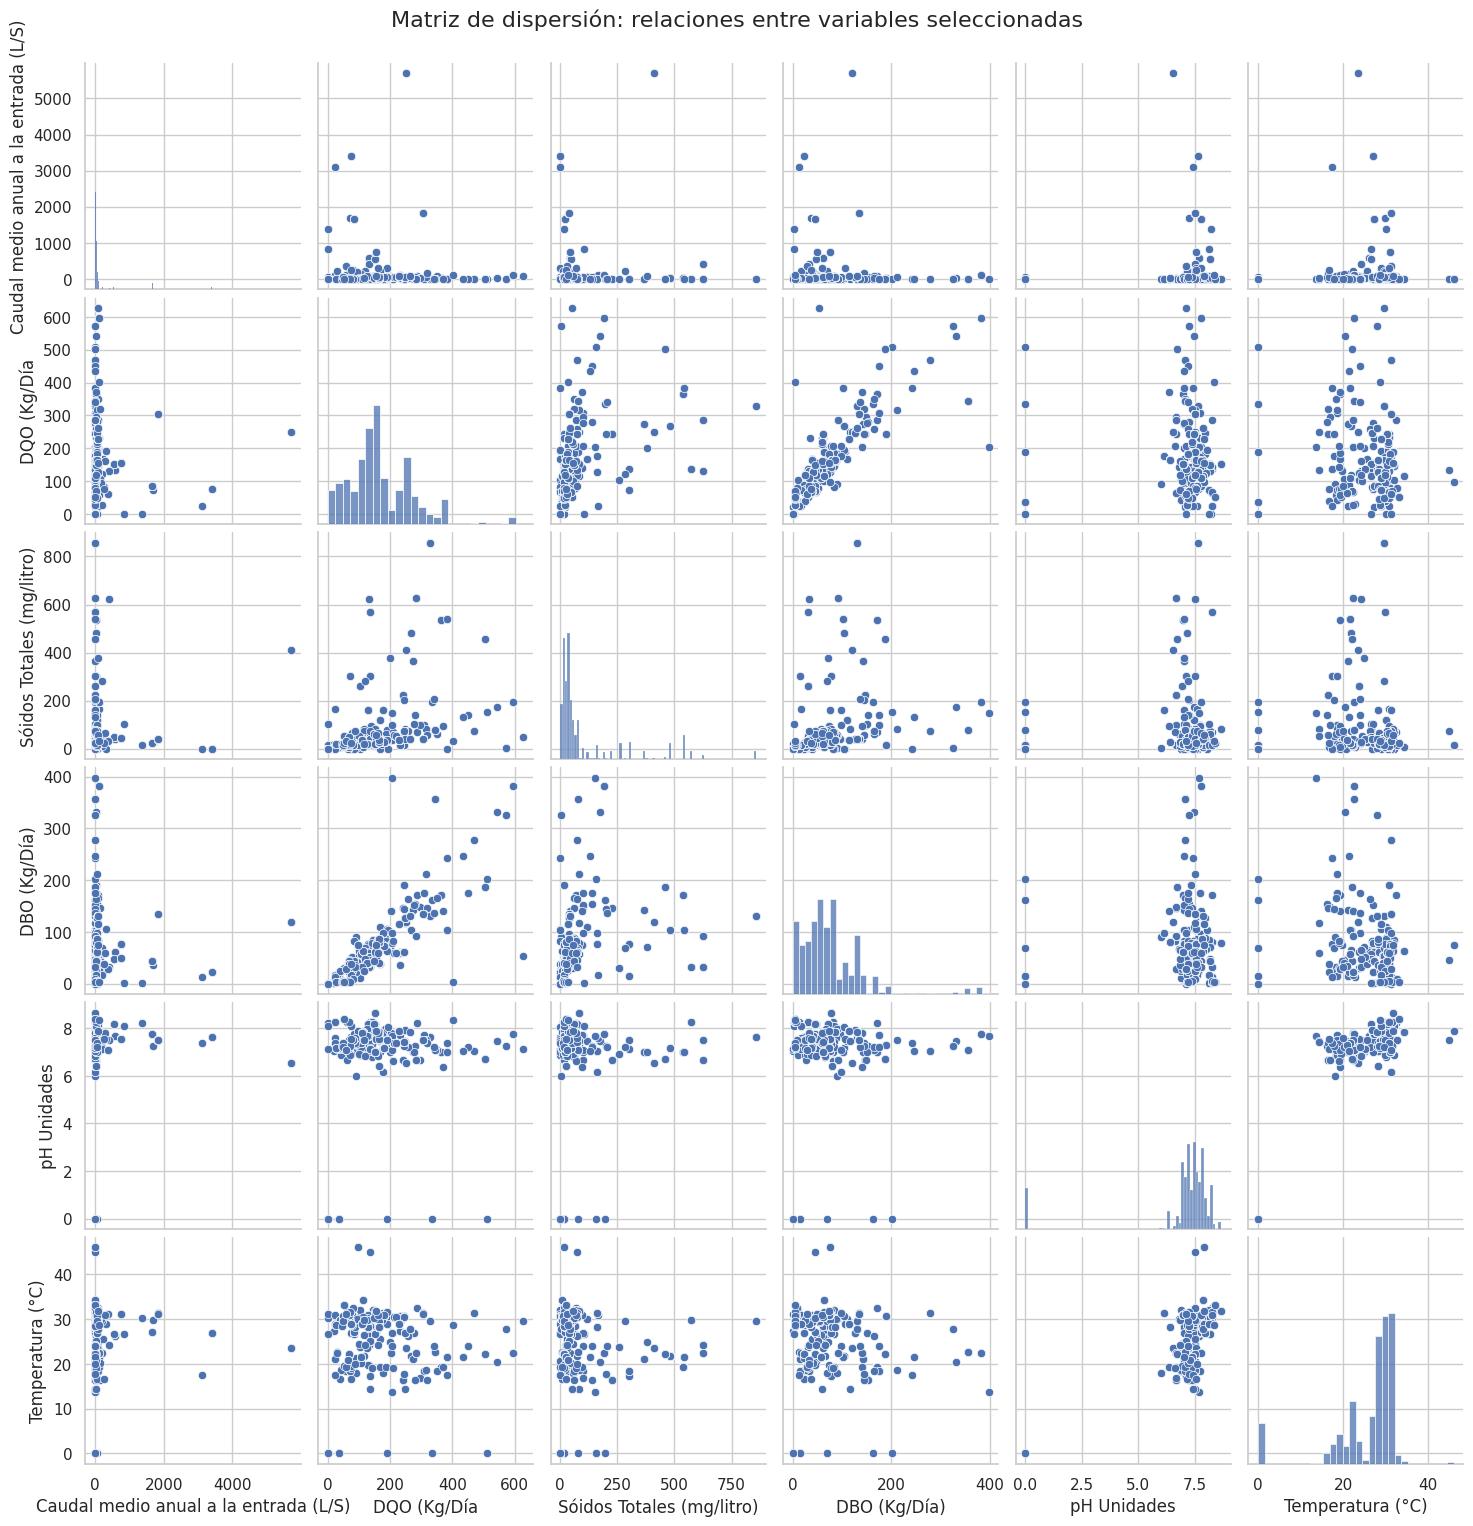

In [14]:
# Seleccionar las columnas numéricas relevantes para PCA
numerical_cols = ['Caudal medio anual a la entrada (L/S)', 'DQO (Kg/Día', 'Sóidos Totales (mg/litro)',
                             'DBO (Kg/Día)', 'pH Unidades', 'Temperatura (°C)']

# Filtrado de datos desde el original
df_clean = df[
    (df['pH Unidades'] <= 14) &
    (df['Temperatura (°C)'] <= 50) &
    (df['Caudal medio anual a la entrada (L/S)'] < 100000) # Eliminamos el outlier de 125k
].copy()

# Crear un DataFrame para el PCA y pairplot
# y eliminando filas con NaN en cualquiera de las columnas seleccionadas
df_for_analysis = df_clean[numerical_cols].dropna()

# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(df_for_analysis)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Visualización con pairplot
sns.pairplot(df_for_analysis, diag_kind='hist', corner=False)
plt.suptitle('Matriz de dispersión: relaciones entre variables seleccionadas', fontsize=16, y=1.02)
plt.show()

En esta gráfica, que si bien tiene similitudes con la anterior, se puede observar que la DBO y la DQO se relacionan positivamente, lo que nos indica que el origen de las aguas tratadas es mayoritariamente dométigo y agroindustrial.

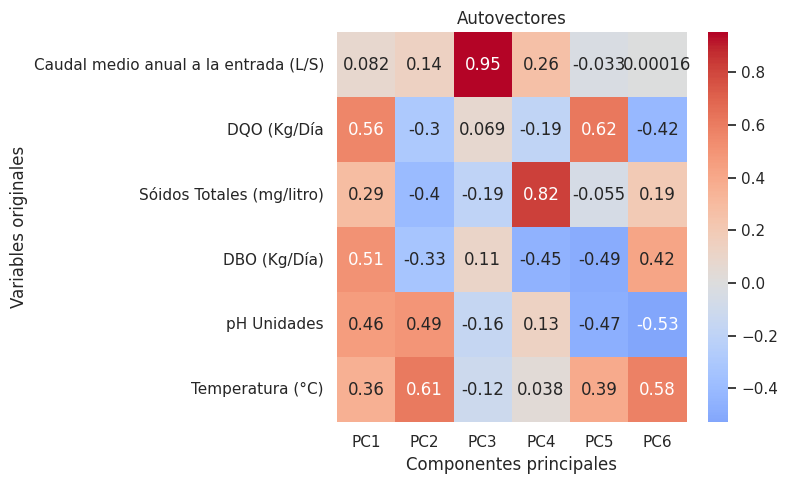

Ecuaciones de los componentes principales:

PC1 = 0.082·'Caudal medio anual a la entrada (L/S)' + 0.561·'DQO (Kg/Día' + 0.292·'Sóidos Totales (mg/litro)' + 0.506·'DBO (Kg/Día)' + 0.458·'pH Unidades' + 0.357·'Temperatura (°C)'
PC2 = 0.137·'Caudal medio anual a la entrada (L/S)' + -0.301·'DQO (Kg/Día' + -0.405·'Sóidos Totales (mg/litro)' + -0.331·'DBO (Kg/Día)' + 0.491·'pH Unidades' + 0.613·'Temperatura (°C)'
PC3 = 0.951·'Caudal medio anual a la entrada (L/S)' + 0.069·'DQO (Kg/Día' + -0.194·'Sóidos Totales (mg/litro)' + 0.111·'DBO (Kg/Día)' + -0.164·'pH Unidades' + -0.116·'Temperatura (°C)'
PC4 = 0.261·'Caudal medio anual a la entrada (L/S)' + -0.192·'DQO (Kg/Día' + 0.82·'Sóidos Totales (mg/litro)' + -0.45·'DBO (Kg/Día)' + 0.134·'pH Unidades' + 0.038·'Temperatura (°C)'
PC5 = -0.033·'Caudal medio anual a la entrada (L/S)' + 0.616·'DQO (Kg/Día' + -0.055·'Sóidos Totales (mg/litro)' + -0.491·'DBO (Kg/Día)' + -0.474·'pH Unidades' + 0.388·'Temperatura (°C)'
PC6 = 0.0·'Caudal medio anual a la e

In [15]:
# Matriz de componentes
componentes = pd.DataFrame(pca.components_.T,
                           columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                           index=df_for_analysis.columns)

# Visualización de autovectores
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0)
plt.title('Autovectores')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# Ecuaciones de los componentes principales con nombres reales
print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{df_for_analysis.columns[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")

Analizando los componentes principales y las variables con mayor peso, encontramos que en el caso del primer componente, la DQO y la DBO tienen las cargas más altas, esto podría indicar que este componente se relaciona con la materia orgánica presente en las aguas luego del tratamiento, adicionalmente, el pH tiene una carga alta, lo que tal vez indica que los cambios en la carga orgánica vienen acompañados variaciones del pH. El segundo componente se relaciona principalmente con la temperatura y el pH, lo que indicaría que permite una separación entre las plantas de acuerdo al clima y la estabilidad química dada por el pH. La tercera dimensión o componente se relaciona fuertemente con el caudal, lo que nos indica el tamaño de la planta y su capacidad de tratamiento, mostrando además que en el país, el tamaño de la planta es independiente de qué tan efectivos son los tratamientos. El cuarto componente nos puede indicar la eficiencia de separación y refuerza la idea de que la cantidad de sólidos no se relaciona con la carga orgánica.

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      2.376  0.396          0.396
1        PC2      1.689  0.281          0.677
2        PC3      0.999  0.166          0.843
3        PC4      0.715  0.119          0.962
4        PC5      0.143  0.024          0.986
5        PC6      0.084  0.014          1.000


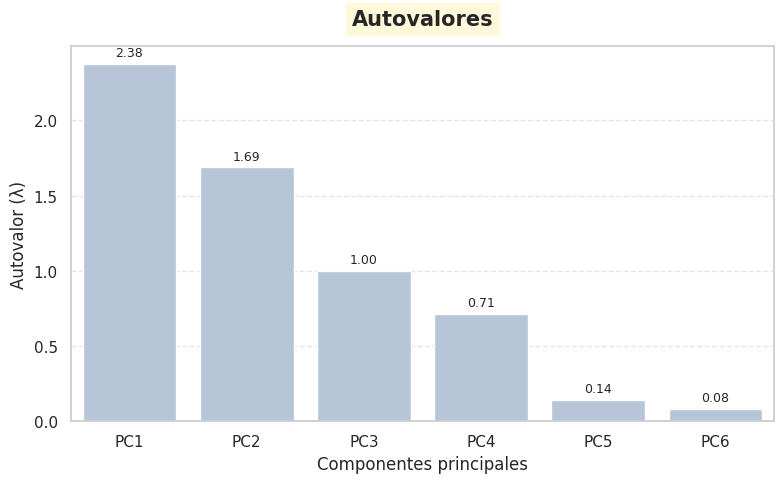

In [16]:
# Varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

# DataFrame para visualización
df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

print("Matriz resumen de varianza explicada:\n")
print(df_varianza.round(3))

# --------------------------
# Gráfico 1: Autovalores
# --------------------------
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
for i, v in enumerate(df_varianza['Autovalor']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.title("Autovalores", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Autovalor (λ)")
plt.xlabel("Componentes principales")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Una vez observada la cantidad de información que captura cada uno de los componentes, se puede utilizar la regla de Kaiser, que dice que solo se conservan los componentes principales con un lambda mayor o igual a 1; para este caso, se conservarían los primeros 3 componentes, donde el primero logra la mayor explicación de la variabilidad, indicando que la carga orgánica es la mayor diferencia entre las plantas de tratamiento de aguas del país, seguido de la temperatura de la región y el pH, y por último el tamaño de la planta que si bien puede ser independiente a la contaminación del agua, es necesario para el sistema.

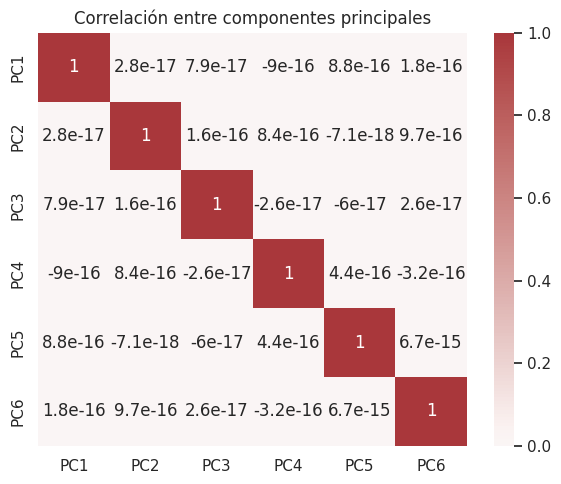

In [21]:
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(PVE))])
correlaciones = df_pca.corr()

# Visualización
plt.figure(figsize=(6, 5))
sns.heatmap(correlaciones, annot=True, cmap='vlag', center=0)
plt.title('Correlación entre componentes principales')
plt.tight_layout()
plt.show()


Por útlimo, esta gráfica nos muestra que los componentes principales son ortogonales, lo que quiere decir que son independientes entre sí, entonces resulta útil y adecuado pasar a 6 dimensiones independientes de las cuales las primeras 3 según la relga de Kaiser, logran explicar las diferencias entre diferentes plantes de tratamiento de aguas del país.